# Notebook 02 – Medical Claim Severity Model EDA

> **Dataset**: `data/generated/severity_training_dataset.csv`  
> **Target**: `average_claim_severity` (Average claim cost per service/claim, computed for clients with at least 1 claim).  
> **Objective**: Analyze the distribution of medical claim severity, validate the lognormal distribution assumption, check for outliers, and identify key predictors for modeling.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import lognorm, norm

ROOT = Path().resolve()
while not (ROOT / "data").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

# Load severity training dataset
dataset_path = ROOT / "data/generated/severity_training_dataset.csv"
sev = pd.read_csv(dataset_path)
print(f"Loaded dataset from: {dataset_path}")
print(f"Shape: {sev.shape}")

Loaded dataset from: /home/viet6cltt/Dev/Viettel_Project/Dynamic_Insurance_Pricing_System/data/generated/severity_training_dataset.csv
Shape: (166877, 18)


## 1. Minimal Data Validation

Verify that all target values (`average_claim_severity`) are strictly positive, as the severity model only trains on clients who had at least 1 claim, and log-transform requires positive values.

In [2]:
print("=== Target Verification ===")
target = sev["average_claim_severity"]
is_positive = np.all(target > 0)
print(f"- target (average_claim_severity) is strictly positive: {is_positive}")
print(f"- Minimum severity: {target.min():.2f}")
print(f"- Maximum severity: {target.max():.2f}")
print(f"- Missing target values: {target.isna().sum()}")

=== Target Verification ===
- target (average_claim_severity) is strictly positive: True
- Minimum severity: 2.09
- Maximum severity: 1067.01
- Missing target values: 0


## 2. Target Distribution and Log-Transform Diagnostic

Medical claim costs typically have a highly skewed, right-tailed distribution (often modeled with Lognormal or Gamma distributions). Let's visualize the raw target vs its log-transform.

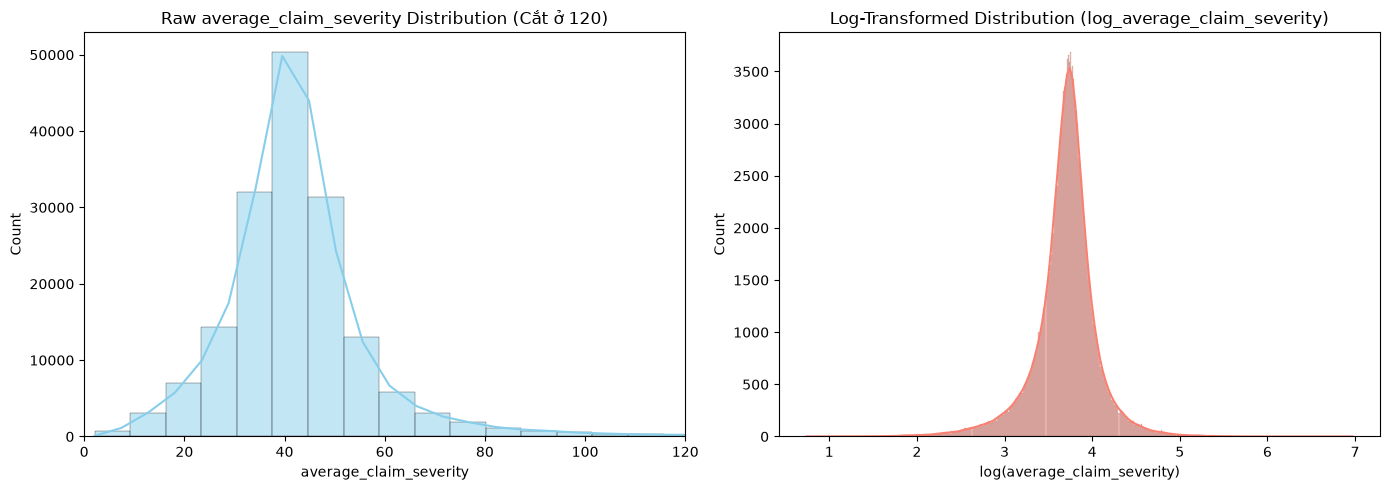

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Target Distribution
sns.histplot(target, kde=True, ax=axes[0], color="skyblue", bins=150)
axes[0].set_xlim(0, 120)
axes[0].set_title("Raw average_claim_severity Distribution (Cắt ở 120)")
axes[0].set_xlabel("average_claim_severity")

# Log-transformed Target Distribution
log_target = np.log(target)
sns.histplot(log_target, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Log-Transformed Distribution (log_average_claim_severity)")
axes[1].set_xlabel("log(average_claim_severity)")

plt.tight_layout()
plt.show()

## 3. Normality Test of Log-Transformed Target

Let's check if the log-transformed target resembles a Normal distribution (justifying a Lognormal OLS model). We plot a Q-Q plot and perform normality diagnostics.

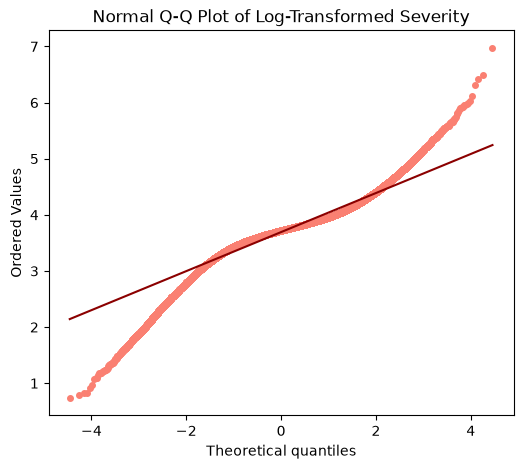

Kolmogorov-Smirnov Test (Normality of log-target):
  - Statistic: 0.0980
  - p-value  : 0.0000e+00


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(log_target, dist="norm", plot=ax)
ax.get_lines()[0].set_color("salmon")
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color("darkred")
ax.set_title("Normal Q-Q Plot of Log-Transformed Severity")
plt.show()

# Kolmogorov-Smirnov test for normality
stat, p_val = stats.kstest(log_target, stats.norm(loc=log_target.mean(), scale=log_target.std()).cdf)
print(f"Kolmogorov-Smirnov Test (Normality of log-target):")
print(f"  - Statistic: {stat:.4f}")
print(f"  - p-value  : {p_val:.4e}")

## 4. Bivariate Analysis: Categorical Features and Severity

We analyze how severity varies across key categorical groups like `smoker`, `pre_existing_condition`, and `type_product`.

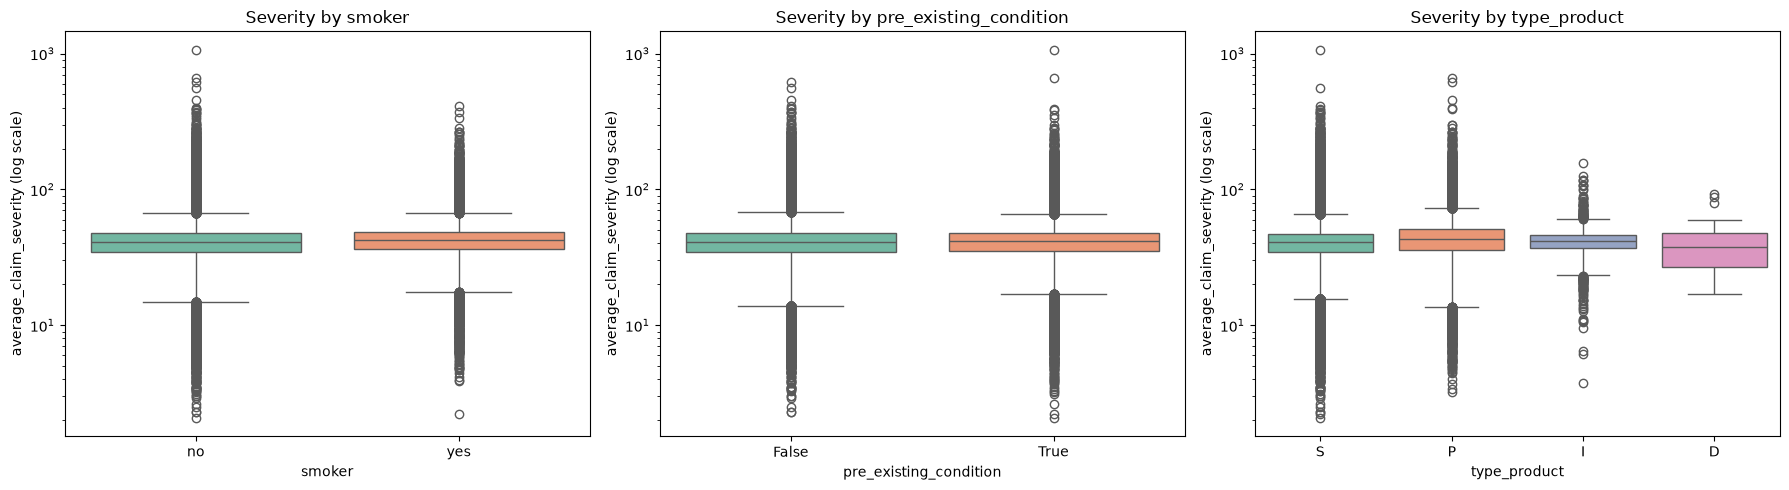


Group Means for smoker:
smoker
no     42.580016
yes    43.753363
Name: average_claim_severity, dtype: float64

Group Means for pre_existing_condition:
pre_existing_condition
False    42.817496
True     42.739675
Name: average_claim_severity, dtype: float64

Group Means for type_product:
type_product
D    42.347500
I    42.248874
P    45.013508
S    42.299263
Name: average_claim_severity, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cat_cols = ["smoker", "pre_existing_condition", "type_product"]

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=sev, x=col, y="average_claim_severity", ax=ax, palette="Set2")
    ax.set_title(f"Severity by {col}")
    ax.set_yscale("log")
    ax.set_ylabel("average_claim_severity (log scale)")

plt.tight_layout()
plt.show()

# Calculate group means
for col in cat_cols:
    print(f"\nGroup Means for {col}:")
    print(sev.groupby(col)["average_claim_severity"].mean())

## 5. Correlation with Numeric Features

Let's check the correlation of numeric features (age, BMI, blood pressure, previous year's claim severity/count) with the target.

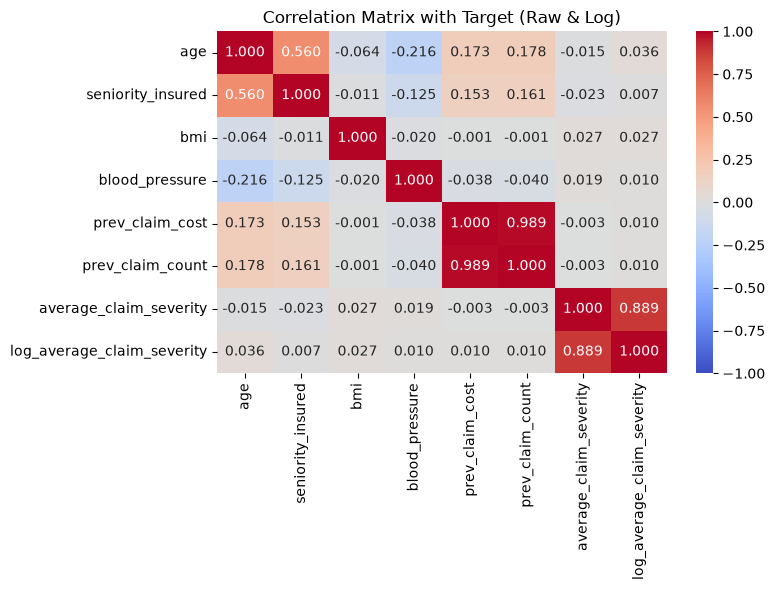

In [6]:
num_cols = ["age", "seniority_insured", "bmi", "blood_pressure", "prev_claim_cost", "prev_claim_count"]
corr_df = sev[num_cols + ["average_claim_severity"]].copy()
corr_df["log_average_claim_severity"] = np.log(corr_df["average_claim_severity"])

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)
plt.title("Correlation Matrix with Target (Raw & Log)")
plt.tight_layout()
plt.show()

## 6. Outlier Detection in Severity

Identify extreme values in severity and see if they belong to specific medical categories or profiles.

=== Top 5 Extreme Severity Claims ===
        average_claim_severity  age     bmi smoker  pre_existing_condition
121271                 1067.01   20  31.790     no                    True
149527                  662.33   69  25.080     no                    True
68662                   613.96   52  32.965     no                   False
133022                  554.36    3  34.400     no                   False
112866                  451.79   84  31.825     no                   False


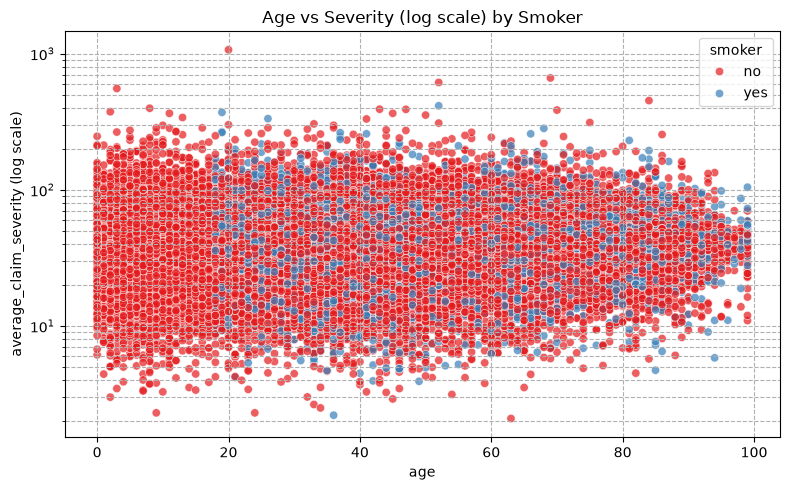

In [7]:
print("=== Top 5 Extreme Severity Claims ===")
print(sev.nlargest(5, "average_claim_severity")[["average_claim_severity", "age", "bmi", "smoker", "pre_existing_condition"]])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sev, x="age", y="average_claim_severity", hue="smoker", alpha=0.7, palette="Set1")
plt.yscale("log")
plt.title("Age vs Severity (log scale) by Smoker")
plt.ylabel("average_claim_severity (log scale)")
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

## 7. Model Recommendations

* **Lognormal assumption**: The log-transformed target has a much more symmetric and bell-shaped distribution, justifying a Lognormal OLS model or an XGBoost Regressor with log-transformed target.
* **Key features**:
  * **Smoker**: Strong indicator of higher medical claim severity.
  * **Age & BMI**: Moderate linear and non-linear relationships.
  * **Pre-existing condition**: Shows higher average claim cost.